In [12]:
import os
from google.colab import drive
import shutil
import sqlite3

# Define paths
google_drive_db_path = '/content/drive/MyDrive/neo_data.db'
default_local_db_path = 'neo_data.db'
alternate_local_db_path = 'neo_data (1).db' # Often created if 'neo_data.db' is uploaded multiple times

final_db_to_use = None

# Helper function to check if a database file contains any tables
def has_tables(db_path):
    if not os.path.exists(db_path):
        return False
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        conn.close()
        return len(tables) > 0
    except sqlite3.Error as e:
        print(f"Warning: Error checking tables in {db_path}: {e}")
        return False

# 1. Mount Google Drive
print('Mounting Google Drive...')
try:
    drive.mount('/content/drive', force_remount=True) # force_remount for robustness
    print('Google Drive mounted.')
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

# 2. Try to identify a suitable local file based on validity
if has_tables(alternate_local_db_path):
    print(f"'{alternate_local_db_path}' found locally and contains tables. Using this file.")
    final_db_to_use = alternate_local_db_path
elif has_tables(default_local_db_path):
    print(f"'{default_local_db_path}' found locally and contains tables. Using this file.")
    final_db_to_use = default_local_db_path
elif os.path.exists(google_drive_db_path):
    print(f"'{google_drive_db_path}' found in Google Drive. Attempting to copy to '{default_local_db_path}'...")
    try:
        shutil.copy(google_drive_db_path, default_local_db_path)
        if has_tables(default_local_db_path):
            print(f"Successfully copied '{google_drive_db_path}' to '{default_local_db_path}' and it contains tables. Using '{default_local_db_path}'.")
            final_db_to_use = default_local_db_path
        else:
            print(f"Copied '{default_local_db_path}' from Drive, but it contains no tables. Will not use it.")
    except Exception as e:
        print(f"Error copying from Google Drive: {e}")
else:
    print(f"Error: No valid database file found. '{google_drive_db_path}' not found in Google Drive, and neither '{default_local_db_path}' nor '{alternate_local_db_path}' are present locally or valid.")
    print("Please ensure 'neo_data.db' is placed in the root of your Google Drive's 'My Drive' folder, or upload it directly to Colab (e.g. using `from google.colab import files; uploaded = files.upload()`).")

# 3. Connect to the database and list tables if available
if final_db_to_use:
    conn = sqlite3.connect(final_db_to_use)
    try:
        tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
        print(f'Using database: {final_db_to_use}')
        print('Tables:', [t[0] for t in tables])
        if not tables:
            print("No tables found in the database. Please ensure the selected 'neo_data.db' contains the necessary tables like 'neo_features' and 'neo_objects'.")
        for t in tables:
            count = conn.execute(f"SELECT COUNT(*) FROM {t[0]} LIMIT 1;").fetchone()[0] # Limit to 1 for efficiency
            print(f"  {t[0]}: {count} rows")
    except Exception as e:
        print(f"Error querying database '{final_db_to_use}': {e}")
    finally:
        conn.close()
else:
    print("Cannot connect to database: No valid 'neo_data.db' file found.")


Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted.
'neo_data (1).db' found locally and contains tables. Using this file.
Using database: neo_data (1).db
Tables: ['neo_objects', 'close_approaches', 'sqlite_sequence', 'neo_features', 'scraper_runs', 'scraper_state']
  neo_objects: 61908 rows
  close_approaches: 863650 rows
  sqlite_sequence: 2 rows
  neo_features: 45955 rows
  scraper_runs: 8 rows
  scraper_state: 2 rows


In [13]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print('Imports OK')

Imports OK


In [17]:
import pandas as pd
import sqlite3

# Ensure final_db_to_use is defined. It should be from the previous cell.
# If this cell is run independently, it might need re-evaluation of lLOdY80DD2qw.
if 'final_db_to_use' not in locals() or final_db_to_use is None:
    print("Error: 'final_db_to_use' not set. Please run the cell above to determine the correct database file.")
else:
    conn = sqlite3.connect(final_db_to_use)

    try:
        df = pd.read_sql_query("""
            SELECT
                f.neo_id,
                n.name,

                -- ── Features (X) — orbital elements only ──────────────────────────
                f.absolute_magnitude_h,
                f.diameter_mean_km,
                f.eccentricity,
                f.semi_major_axis,
                f.inclination,
                f.perihelion_distance,
                f.aphelion_distance,
                f.orbital_period,
                f.perihelion_crosses_earth_orbit,
                f.ecc_x_inclination,
                f.orbit_class_encoded,

                -- ── Target (y) ────────────────────────────────────────────────────
                f.risk_score_normalized,

                -- ── Reference only (NOT passed to model) ─────────────────────────
                f.risk_tier,
                f.ca_min_miss_au,
                f.ca_count,
                n.is_potentially_hazardous

            FROM neo_features f
            JOIN neo_objects n ON f.neo_id = n.id
            WHERE f.risk_score_normalized IS NOT NULL
        """, conn)

        print(f'Loaded {len(df):,} NEOs')
        print(f'Columns: {list(df.columns)}')
        display(df.head(3))
    except Exception as e:
        print(f"Error loading data from '{final_db_to_use}': {e}")
        # Optionally, print available tables to help debug
        if 'conn' in locals() and conn:
            cursor = conn.cursor()
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
            tables = cursor.fetchall()
            print(f"Available tables in '{final_db_to_use}': {tables}")
    finally:
        if 'conn' in locals() and conn:
            conn.close()


Loaded 45,955 NEOs
Columns: ['neo_id', 'name', 'absolute_magnitude_h', 'diameter_mean_km', 'eccentricity', 'semi_major_axis', 'inclination', 'perihelion_distance', 'aphelion_distance', 'orbital_period', 'perihelion_crosses_earth_orbit', 'ecc_x_inclination', 'orbit_class_encoded', 'risk_score_normalized', 'risk_tier', 'ca_min_miss_au', 'ca_count', 'is_potentially_hazardous']


,neo_id,name,absolute_magnitude_h,diameter_mean_km,eccentricity,semi_major_axis,inclination,perihelion_distance,aphelion_distance,orbital_period,perihelion_crosses_earth_orbit,ecc_x_inclination,orbit_class_encoded,risk_score_normalized,risk_tier,ca_min_miss_au,ca_count,is_potentially_hazardous
0,2000433,433 Eros (A898 PA),10.40,35.771950,0.222878,1.458244,10.828544,1.133233,1.783254,643.196389,0,2.413444,0,3.183317,CRITICAL,0.149462,42,0
1,2000887,887 Alinda (A918 AA),13.82,7.405299,0.571084,2.473999,9.399998,1.061137,3.886861,1421.339070,0,5.368190,0,2.731596,CRITICAL,0.082198,5,0
2,2001221,1221 Amor (1932 EA1),17.37,1.443918,0.434731,1.919716,11.870129,1.085156,2.754276,971.525135,0,5.160312,0,1.391945,HIGH,0.105277,40,0


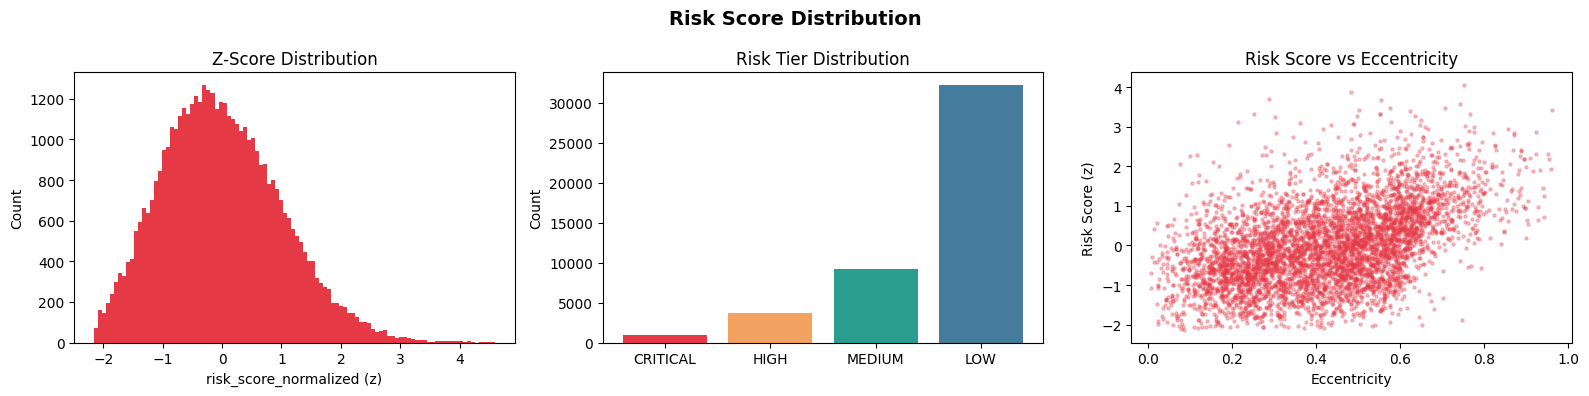

Distribution looks healthy if z-scores are roughly bell-curved.


In [18]:
#EDA — Distribution check
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Risk Score Distribution', fontsize=14, fontweight='bold')

# Raw risk score (log scale)
axes[0].hist(df['risk_score_normalized'], bins=100, color='#e63946', edgecolor='none')
axes[0].set_title('Z-Score Distribution')
axes[0].set_xlabel('risk_score_normalized (z)')
axes[0].set_ylabel('Count')

# Tier breakdown
tier_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
tier_colors = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d']
tier_counts = df['risk_tier'].value_counts().reindex(tier_order)
axes[1].bar(tier_counts.index, tier_counts.values, color=tier_colors)
axes[1].set_title('Risk Tier Distribution')
axes[1].set_ylabel('Count')

# Risk score vs eccentricity
sample = df.sample(min(5000, len(df)), random_state=42)
axes[2].scatter(sample['eccentricity'], sample['risk_score_normalized'],
                alpha=0.3, s=5, c='#e63946')
axes[2].set_title('Risk Score vs Eccentricity')
axes[2].set_xlabel('Eccentricity')
axes[2].set_ylabel('Risk Score (z)')

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Distribution looks healthy if z-scores are roughly bell-curved.')

In [19]:
#Feature matrix + train/test split
FEATURE_COLS = [
    'absolute_magnitude_h',
    'diameter_mean_km',
    'eccentricity',
    'semi_major_axis',
    'inclination',
    'perihelion_distance',
    'aphelion_distance',
    'orbital_period',
    'perihelion_crosses_earth_orbit',
    'ecc_x_inclination',
    'orbit_class_encoded',
]
TARGET_COL = 'risk_score_normalized'

# Drop rows with any missing features
df_clean = df[FEATURE_COLS + [TARGET_COL, 'name', 'risk_tier']].dropna()
print(f'Clean dataset: {len(df_clean):,} rows (dropped {len(df) - len(df_clean):,} with nulls)')

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET_COL].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_clean.index, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Clean dataset: 45,955 rows (dropped 0 with nulls)
Train: 36,764 | Test: 9,191


In [20]:
model = XGBRegressor(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,    # L1 regularization
    reg_lambda        = 1.0,    # L2 regularization
    objective         = 'reg:squarederror',
    eval_metric       = 'rmse',
    early_stopping_rounds = 30,
    random_state      = 42,
    n_jobs            = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-rmse:0.96519	validation_1-rmse:0.97651
[50]	validation_0-rmse:0.53629	validation_1-rmse:0.54280
[100]	validation_0-rmse:0.51475	validation_1-rmse:0.52838
[150]	validation_0-rmse:0.50455	validation_1-rmse:0.52585
[200]	validation_0-rmse:0.49482	validation_1-rmse:0.52536
[250]	validation_0-rmse:0.48618	validation_1-rmse:0.52443
[300]	validation_0-rmse:0.47791	validation_1-rmse:0.52409
[350]	validation_0-rmse:0.46991	validation_1-rmse:0.52344
[400]	validation_0-rmse:0.46248	validation_1-rmse:0.52276
[450]	validation_0-rmse:0.45531	validation_1-rmse:0.52223
[499]	validation_0-rmse:0.44848	validation_1-rmse:0.52142

Best iteration: 496


In [ ]:
#visualize the model/tree


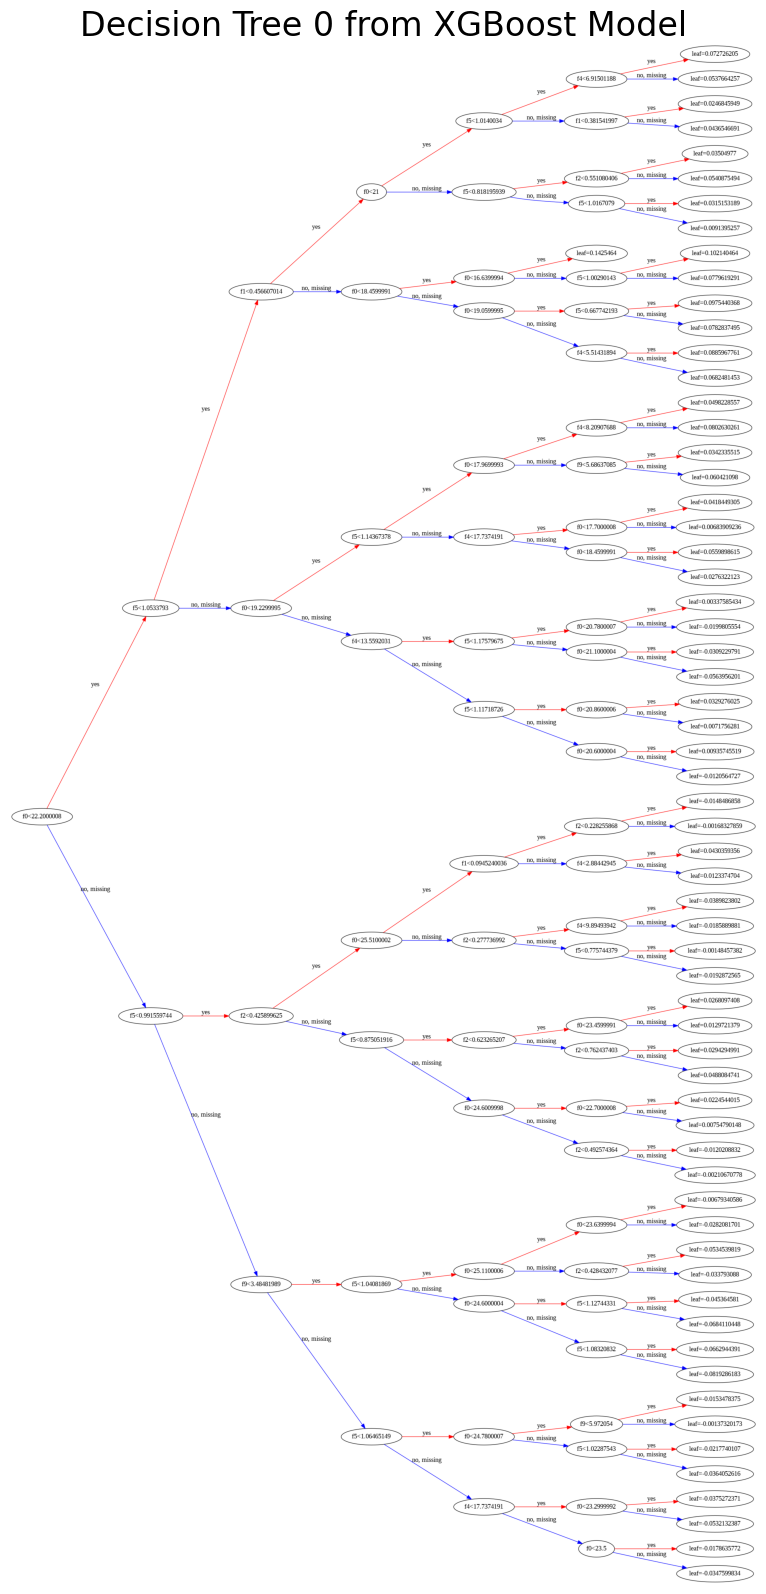

In [21]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

# Visualize the first tree (index 0) in the booster
fig, ax = plt.subplots(figsize=(20, 20)) # Adjust figure size for better readability
plot_tree(model, num_trees=0, ax=ax, rankdir='LR') # rankdir='LR' makes the tree horizontal
plt.title('Decision Tree 0 from XGBoost Model', fontsize=24)
plt.show()

This visualization shows the structure of the *first* decision tree within the XGBoost ensemble. Each node represents a decision based on a feature, leading to a predicted output. This helps in understanding how the model makes predictions for a single tree.

In [22]:
# ── Cell 8: Evaluation ────────────────────────────────────────────────────────
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)
test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae   = mean_absolute_error(y_test, y_pred_test)

print('━' * 45)
print('  MODEL EVALUATION')
print('━' * 45)
print(f'  Train R²   : {train_r2:.4f}')
print(f'  Test  R²   : {test_r2:.4f}   ← key metric')
print(f'  Test  RMSE : {test_rmse:.4f}')
print(f'  Test  MAE  : {test_mae:.4f}')
print('━' * 45)

if test_r2 > 0.85:
    print('  ✅ Strong — orbital elements predict risk well')
elif test_r2 > 0.65:
    print('  ⚠️  Decent — some risk variance not captured by orbital elements alone')
else:
    print('  ❌ Weak — check for data issues or feature leakage')

# Overfitting check
gap = train_r2 - test_r2
print(f'\n  Train/Test R² gap: {gap:.4f}', '✅ OK' if gap < 0.1 else '⚠️ Possible overfit')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL EVALUATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train R²   : 0.7976
  Test  R²   : 0.7334   ← key metric
  Test  RMSE : 0.5213
  Test  MAE  : 0.3724
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚠️  Decent — some risk variance not captured by orbital elements alone

  Train/Test R² gap: 0.0642 ✅ OK


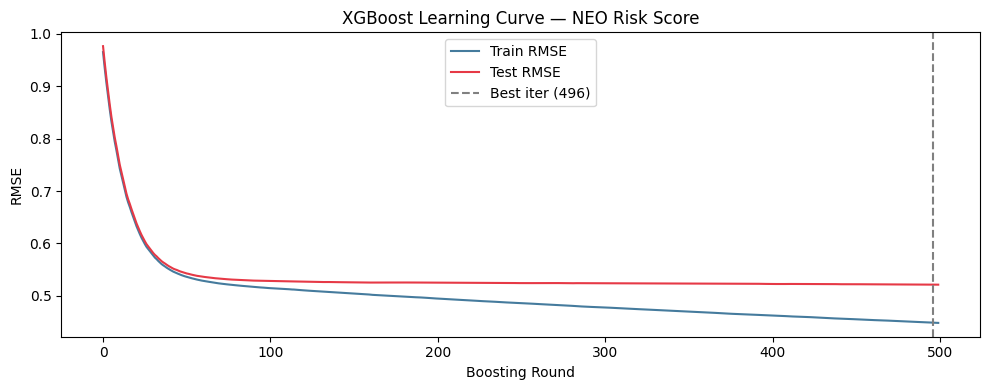

In [23]:
#Learning curve (loss over boosting rounds)
results = model.evals_result()
train_loss = results['validation_0']['rmse']
test_loss  = results['validation_1']['rmse']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train RMSE', color='#457b9d')
plt.plot(test_loss,  label='Test RMSE',  color='#e63946')
plt.axvline(model.best_iteration, color='gray', linestyle='--', label=f'Best iter ({model.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve — NEO Risk Score')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

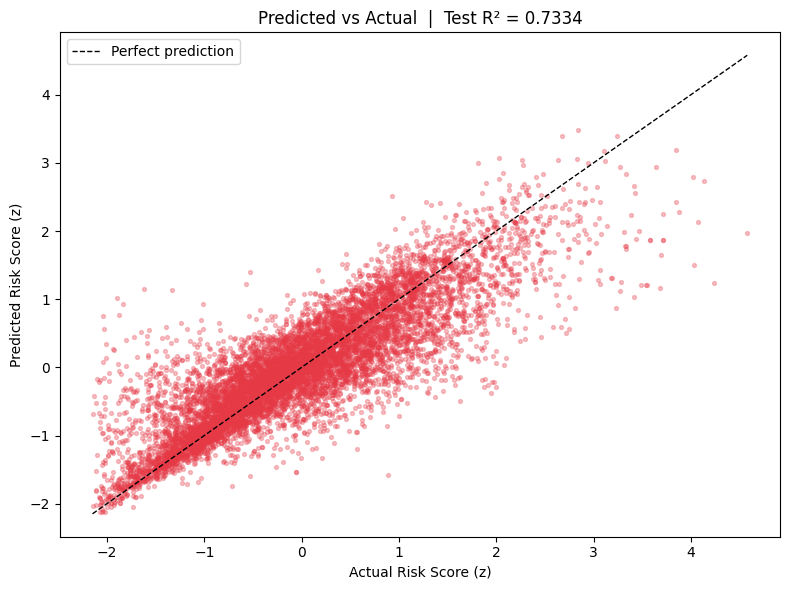

In [24]:
#Cell 10: Predicted vs Actual scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=8, c='#e63946')
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual Risk Score (z)')
plt.ylabel('Predicted Risk Score (z)')
plt.title(f'Predicted vs Actual  |  Test R² = {test_r2:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

Computing SHAP values (may take ~1-2 min)...


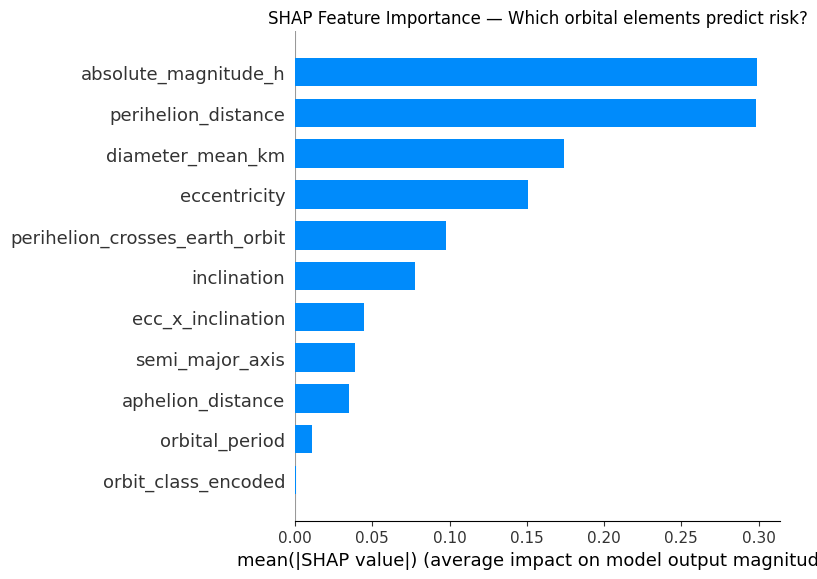

In [25]:
# ── Cell 11: SHAP Analysis ────────────────────────────────────────────────────
# SHAP tells us WHICH orbital features drive risk predictions
# and by HOW MUCH — this is the scientifically interesting output

print('Computing SHAP values (may take ~1-2 min)...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary bar plot — global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Which orbital elements predict risk?')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

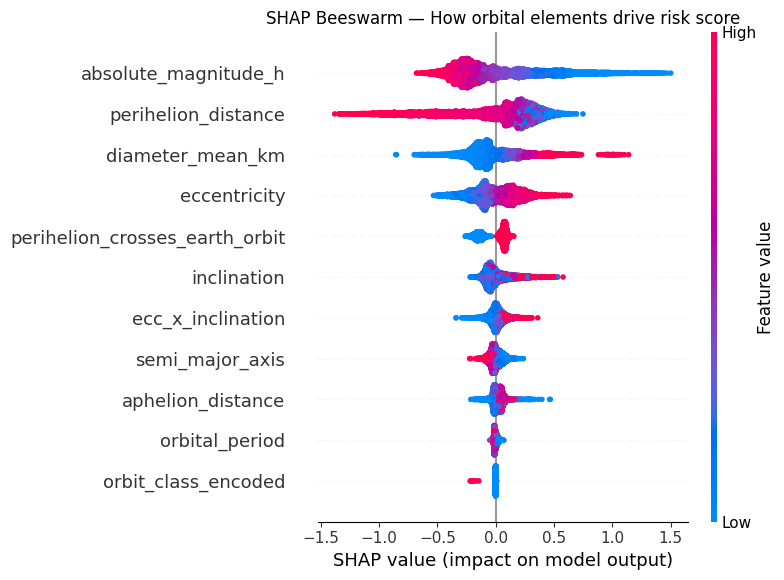


Reading the beeswarm:
  Red dots  = high feature value
  Blue dots = low feature value
  Right of 0 = pushes risk UP
  Left of 0  = pushes risk DOWN


In [26]:
# SHAP Beeswarm — direction + magnitude ───────────────────────────
# Shows not just importance but HOW each feature pushes the score up or down

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Beeswarm — How orbital elements drive risk score')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Reading the beeswarm:')
print('  Red dots  = high feature value')
print('  Blue dots = low feature value')
print('  Right of 0 = pushes risk UP')
print('  Left of 0  = pushes risk DOWN')

In [27]:
 #Final risk ranking table
df_test = df_clean.iloc[idx_test].copy()
df_test['predicted_risk'] = y_pred_test
df_test['actual_risk']    = y_test
df_test['error']          = abs(df_test['predicted_risk'] - df_test['actual_risk'])

top20 = df_test.sort_values('predicted_risk', ascending=False).head(20)

print('\n TOP 20 RISKIEST NEOs (model-predicted ranking)')
print('─' * 72)
print(f'{"Rank":<5} {"Name":<32} {"Predicted z":>11} {"Actual z":>9} {"Tier":<10}')
print('─' * 72)
for i, (_, row) in enumerate(top20.iterrows(), 1):
    name = str(row['name'])[:30]
    print(f'{i:<5} {name:<32} {row["predicted_risk"]:>11.4f} {row["actual_risk"]:>9.4f} {row["risk_tier"]:<10}')
print('─' * 72)


 TOP 20 RISKIEST NEOs (model-predicted ranking)
────────────────────────────────────────────────────────────────────────
Rank  Name                             Predicted z  Actual z Tier      
────────────────────────────────────────────────────────────────────────
1     139359 (2001 ME1)                     3.4887    2.8420 CRITICAL  
2     3752 Camillo (1985 PA)                3.3980    3.2459 CRITICAL  
3     276049 (2002 CE26)                    3.3901    2.6780 CRITICAL  
4     1866 Sisyphus (1972 XA)               3.1938    3.8464 CRITICAL  
5     66008 (1998 QH2)                      3.1751    3.1026 CRITICAL  
6     154278 (2002 TB9)                     3.0674    2.0295 HIGH      
7     343158 Marsyas (2009 HC82)            3.0544    2.8337 CRITICAL  
8     52762 (1998 MT24)                     3.0411    2.6367 CRITICAL  
9     504074 (2006 AD)                      3.0376    2.2694 CRITICAL  
10    86039 (1999 NC43)                     3.0258    3.1196 CRITICAL  
11    401857 

In [28]:
# Save model + download all outputs
import pickle, zipfile, os

# Save model
model.save_model('neo_risk_xgboost.json')
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

# Zip everything
output_files = [
    'neo_risk_xgboost.json',
    'feature_cols.pkl',
    'risk_distribution.png',
    'learning_curve.png',
    'predicted_vs_actual.png',
    'shap_importance.png',
    'shap_beeswarm.png',
]

with zipfile.ZipFile('monarch_neo_outputs.zip', 'w') as z:
    for f in output_files:
        if os.path.exists(f):
            z.write(f)
            print(f'  Added: {f}')

print('\nDownloading outputs...')
files.download('monarch_neo_outputs.zip')
print('Done. Check your downloads folder.')

  Added: neo_risk_xgboost.json
  Added: feature_cols.pkl
  Added: risk_distribution.png
  Added: learning_curve.png
  Added: predicted_vs_actual.png
  Added: shap_importance.png
  Added: shap_beeswarm.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Check your downloads folder.
